# Developing Multi-agent Systems

This notebook consolidates the key concepts from both slide decks:
1. *Understanding Fundamental Concepts of Multi-agent Systems*
2. *Advanced Scenarios in Multi-agent Systems*

In [1]:
from IPython.display import HTML, display
from PIL import Image as PILImage
import base64, io, os

ASSETS = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'assets')

def show(filename, pct=100):
    path = os.path.join(ASSETS, filename)
    img = PILImage.open(path)
    w, h = img.size
    new_w = int(w * pct / 100)
    new_h = int(h * pct / 100)
    img = img.resize((new_w, new_h), PILImage.LANCZOS)
    buf = io.BytesIO()
    img.save(buf, format='PNG')
    b64 = base64.b64encode(buf.getvalue()).decode()
    display(HTML(f'<div style="text-align:center"><img src="data:image/png;base64,{b64}" width="{new_w}" height="{new_h}"/></div>'))

---
## Part 1: Understanding Fundamental Concepts of Multi-agent Systems

### Introduction

**Topics covered:**
- Multi-agent System (MAS) Concepts — architecture patterns, organizational structure, examples
- Hands-on Demos using LangGraph — *"Dressing Right for the Weather"*
- Game Theory Fundamentals
- Game-theoretic Strategies for LLM-based Agentic Systems

**Pre-requisite:** *Introduction to Developing AI Agents* (fundamentals of AI Agents, different types, LangGraph intro)

---
### What is an Agent?

> **"An agent is anything that can perceive its environment and act upon that environment."**

### Architecture and Key Components of AI Agents


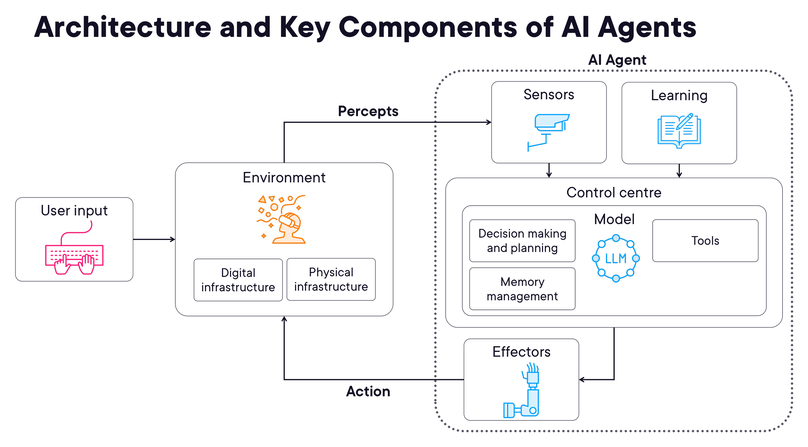

In [2]:
show('agent-architecture.png', 30)

| Component | Role |
|-----------|------|
| **Sensors** | Perceive the environment (inputs) |
| **Learning** | Adapt and improve over time |
| **Control Centre** | Decision making, planning, memory |
| **LLM Model** | The reasoning engine |
| **Tools** | External capabilities the agent can call |
| **Effectors** | Execute actions back into the environment |

---
### What is a Multi-agent System (MAS)?

> **"A collection of autonomous agents that interact within a shared environment to achieve goals."**

### Key Attributes of Agents in a MAS


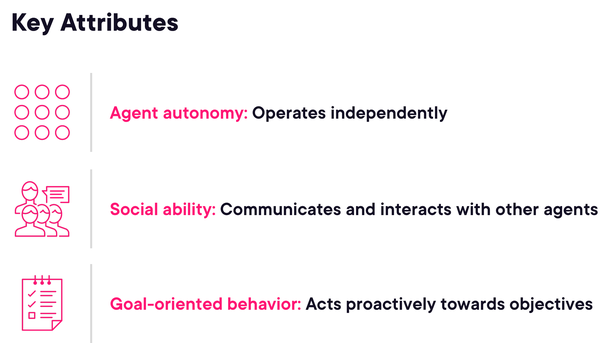

In [3]:
show('mas-key-attributes.png', 25)

| Attribute | Description |
|-----------|-------------|
| **Agent autonomy** | Operates independently |
| **Social ability** | Communicates and interacts with other agents |
| **Goal-oriented behavior** | Acts proactively towards objectives |

### Why Multi-agent?


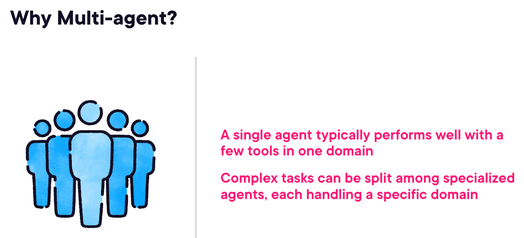

In [4]:
show('why-multi-agent.png', 20)

- A single agent performs well with **few tools in one domain**
- Complex tasks can be **split among specialized agents**, each handling a specific domain

---
### MAS Architecture

Each AI agent contains **Model (M)**, **Memory (M)**, **Tools (T)** plus Sensors, Logic, and Actuators.  
All agents share a common **Environment** and communicate via **Percepts** and **Actions**.


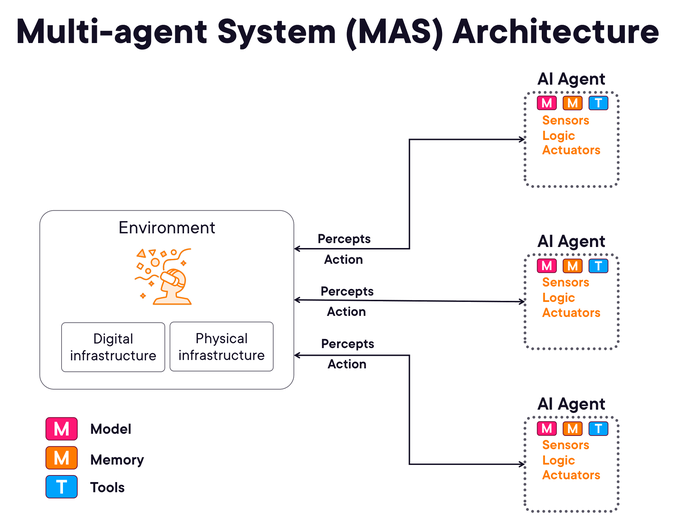

In [5]:
show('mas-architecture.png', 35)

Agents communicate either **directly** (point-to-point messages) or via a **shared mailbox**:


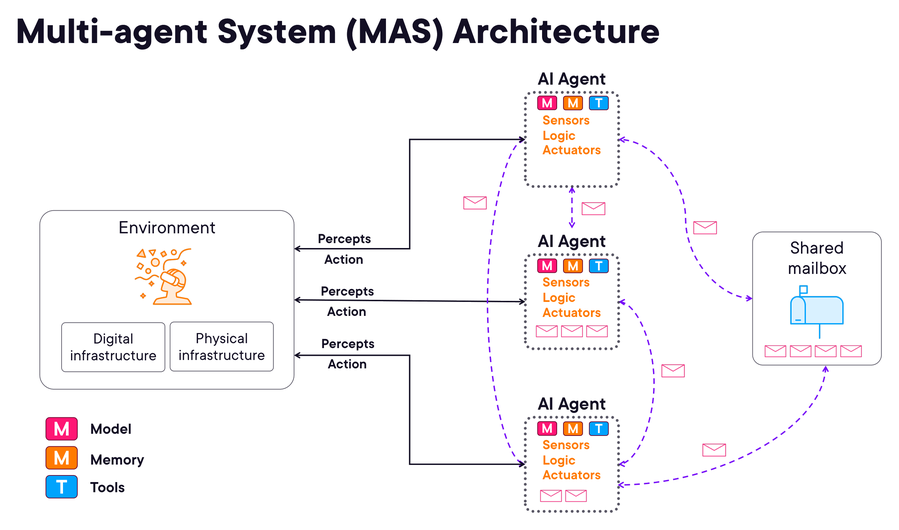

In [6]:
show('mas-architecture-mailbox.png', 35)

---
### Types of Multi-agent Systems


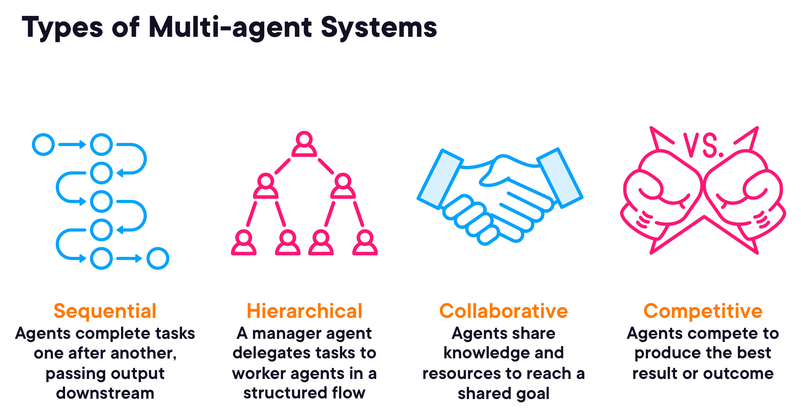

In [7]:
show('mas-types.png', 30)

| Type | Description |
|------|-------------|
| **Sequential** | Agents complete tasks one after another, passing output downstream |
| **Hierarchical** | A manager agent delegates tasks to worker agents in a structured flow |
| **Collaborative** | Agents share knowledge and resources to reach a shared goal |
| **Competitive** | Agents compete to produce the best result or outcome |

---
### Multi-agent Topologies

#### Network (Peer-to-Peer) — any agent can call any other (fully connected)


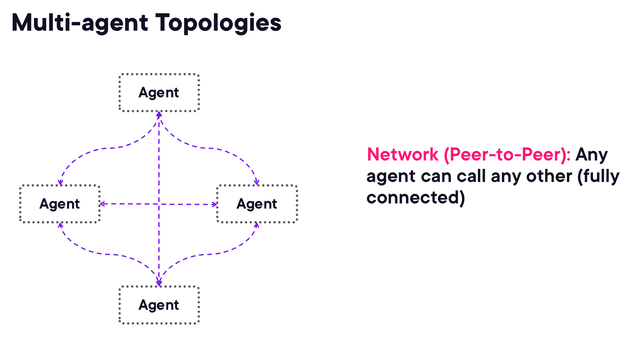

In [8]:
show('topology-network.png', 25)

#### Supervisor (Centralized) — one agent directs/mediates others' actions


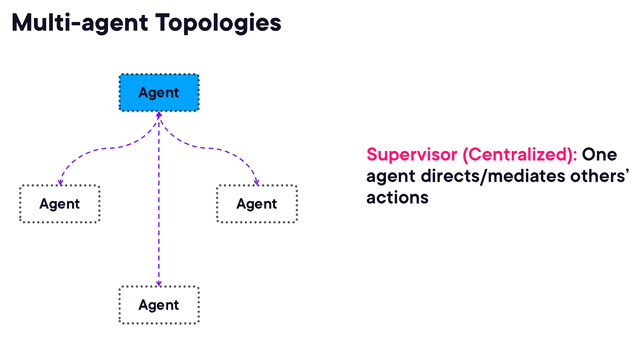

In [9]:
show('topology-supervisor.png', 25)

#### Hierarchical — layered control (supervisor of supervisors)


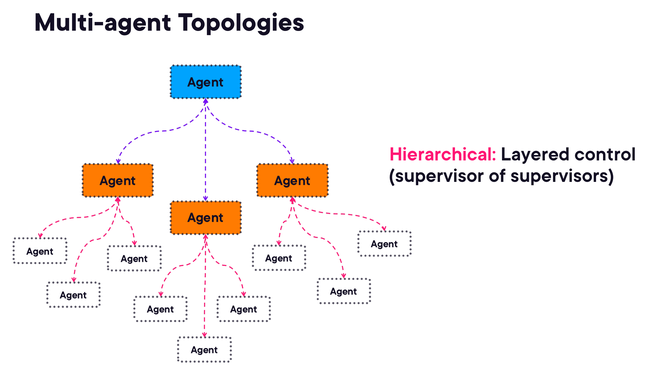

In [10]:
show('topology-hierarchical.png', 25)

---
### LangGraph Key Components


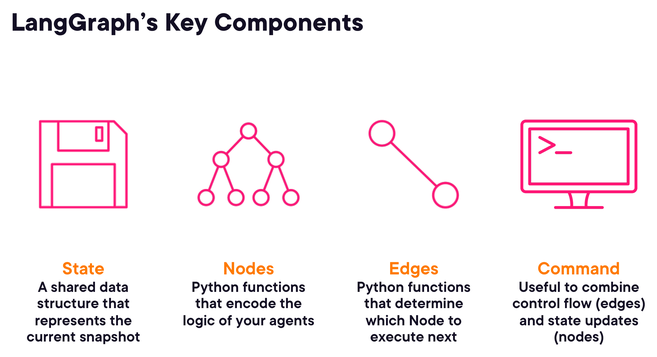

In [11]:
show('langgraph-components.png', 25)

| Component | Description |
|-----------|-------------|
| **State** | A shared data structure representing the current snapshot |
| **Nodes** | Python functions that encode the logic of your agents |
| **Edges** | Python functions that determine which Node to execute next |
| **Command** | Combines control flow (edges) and state updates (nodes) |

```python
def node_a(state: State) -> Command[Literal["node_b"]]:
    return Command(
        update={"foo": "bar"},  # state update
        goto="node_b"           # control flow
    )
```

---
### Agent Interaction and Dependency Relations


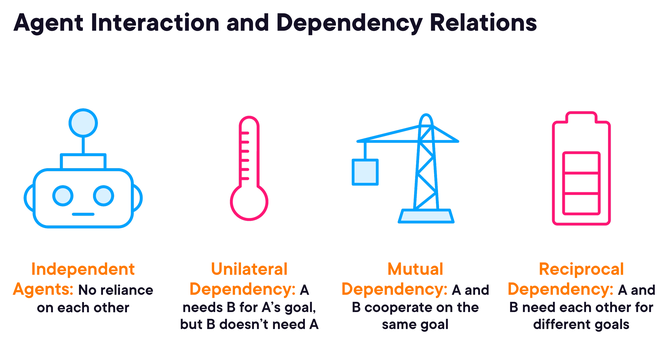

In [12]:
show('agent-dependency-relations.png', 25)

| Dependency Type | Description |
|-----------------|-------------|
| **Independent** | No reliance on each other |
| **Unilateral** | A needs B for A's goal, but B doesn't need A |
| **Mutual** | A and B cooperate on the same goal |
| **Reciprocal** | A and B need each other for different goals |

---
### Common Interaction Strategies Among Agents


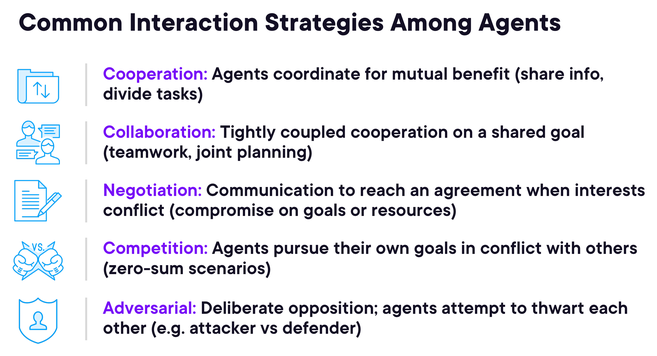

In [13]:
show('interaction-strategies.png', 25)

| Strategy | Description |
|----------|-------------|
| **Cooperation** | Coordinate for mutual benefit (share info, divide tasks) |
| **Collaboration** | Tightly coupled cooperation on a shared goal |
| **Negotiation** | Reach agreement when interests conflict |
| **Competition** | Pursue own goals in conflict with others (zero-sum) |
| **Adversarial** | Deliberate opposition (e.g. attacker vs defender) |

---
### Negotiation in Multi-agent Systems


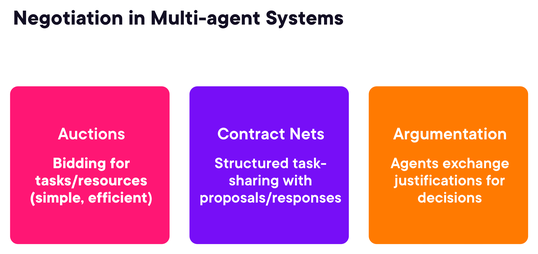

In [14]:
show('negotiation-overview.png', 20)

#### Auctions (Simple, scalable)
- Auctioneer offers a task/resource → others bid → highest (or lowest) bidder wins
- Used for **resource allocation** and **task assignment** — non-cooperative

#### Contract Net (Structured task sharing)
- Manager sends **Call for Proposals** → workers propose terms → manager selects best
- Cooperative negotiation, used for **task allocation**

#### Argumentation (Advanced, rich dialogue)
- Agents exchange arguments explaining proposed actions
- Useful for complex or multi-issue preferences — negotiation via **reasoning & justification**

---
## Part 2: Advanced Scenarios in Multi-agent Systems

### Organizational Structures in MAS


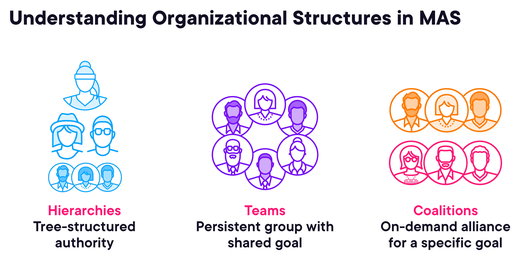

In [15]:
show('org-structures.png', 20)

| Structure | Description |
|-----------|-------------|
| **Hierarchies** | Tree-structured authority |
| **Teams** | Persistent group with shared goal |
| **Coalitions** | On-demand alliance for a specific goal |

### Swarm-style Multi-agent Architecture


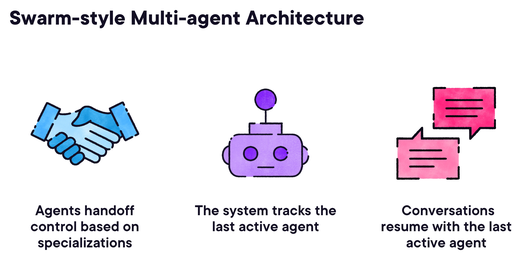

In [16]:
show('swarm-architecture.png', 20)

- Agents **handoff control** based on specializations
- The system **tracks the last active agent**
- Conversations **resume with the last active agent**

---
### Demo: Teams in Multi-agent System
**Dressing Planner Team** — supervisor-based team using LangGraph


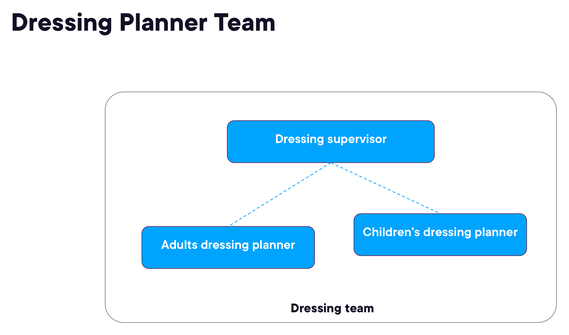

In [17]:
show('dressing-team.png', 25)

The **Dressing Supervisor** delegates to specialized sub-agents (Adults Planner / Children's Planner) based on the user's needs.

---
### Demo: Hierarchies — "Dressing Right for the Weather"
Hierarchical MAS using LangGraph Supervisor (multiple supervisors)


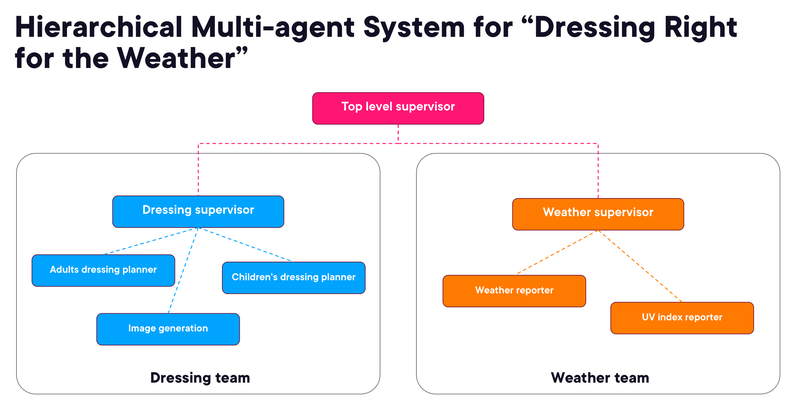

In [18]:
show('hierarchical-dressing-weather.png', 30)

Two specialized teams (**Dressing Team** + **Weather Team**) work under a **Top Level Supervisor** to answer *"What should I wear today?"*

- **Dressing Team:** Dressing Supervisor → Adults Planner, Children's Planner, Image Generation
- **Weather Team:** Weather Supervisor → Weather Reporter, UV Index Reporter

---
## Part 3: Game Theory for Multi-agent Systems

> **"Study of strategic interactions between rational decision-makers, who must choose actions based on how they believe others will act."**

### Kinds of Games


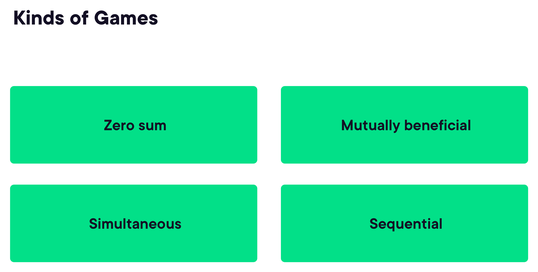

In [19]:
show('game-kinds.png', 20)

| Type | Description |
|------|-------------|
| **Zero-sum** | One agent's gain is another's loss |
| **Mutually beneficial** | All agents can benefit simultaneously |
| **Simultaneous** | All agents choose actions at the same time |
| **Sequential** | Agents take turns making decisions |

### Components of a Game


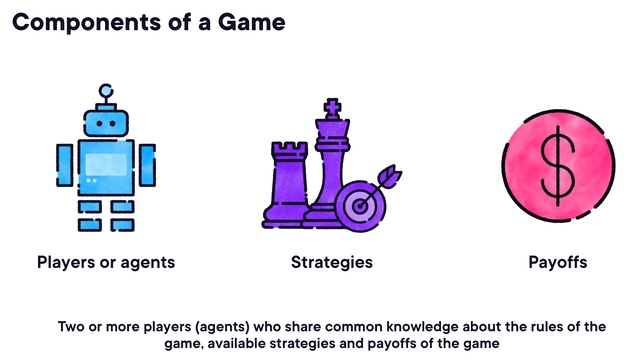

In [20]:
show('game-components.png', 25)

- **Players / Agents** — two or more rational decision-makers with shared knowledge of rules
- **Strategies** — the possible actions each player can take
- **Payoffs** — the outcome/reward for each combination of strategies

#### Common Applications
| Domain | Use Case |
|--------|----------|
| Economics & business | Pricing, market competition, auctions |
| Political science | Negotiation, conflict resolution, voting |
| AI & robotics | Autonomous decision-making, multi-agent coordination |
| Everyday decisions | Negotiations, auctions, social interactions |

---
### Complete vs. Incomplete Information Games


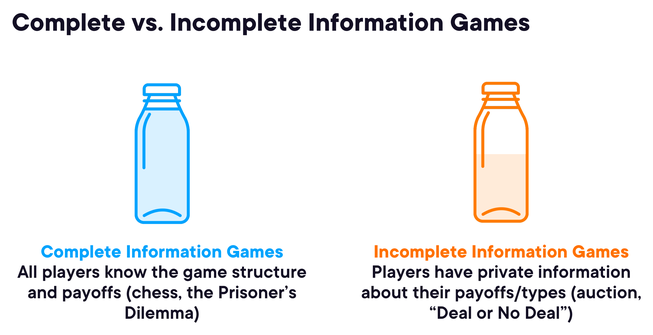

In [21]:
show('complete-vs-incomplete-info.png', 25)

| Type | Description | Examples |
|------|-------------|----------|
| **Complete Information** | All players know the game structure and payoffs | Chess, Prisoner's Dilemma |
| **Incomplete Information** | Players have private info about their payoffs/types | Auctions, "Deal or No Deal" |

---
### The Prisoner's Dilemma


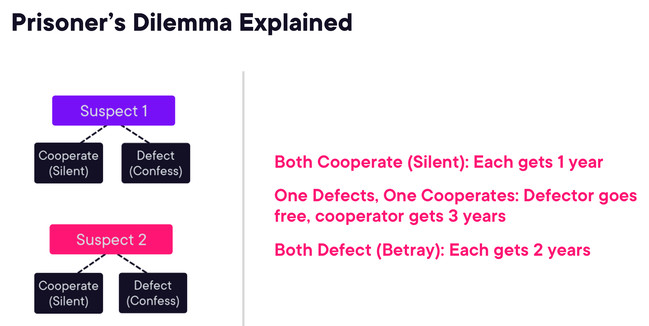

In [22]:
show('prisoners-dilemma-explained.png', 25)

**Setup:** Two suspects interrogated separately — each can stay silent (cooperate) or testify (defect).

- Both cooperate (silent): each gets **1 year**
- One defects, one cooperates: defector goes **free**, cooperator gets **3 years**
- Both defect (betray): each gets **2 years**

### Payoff Matrix — Final State (with Nash Equilibrium)


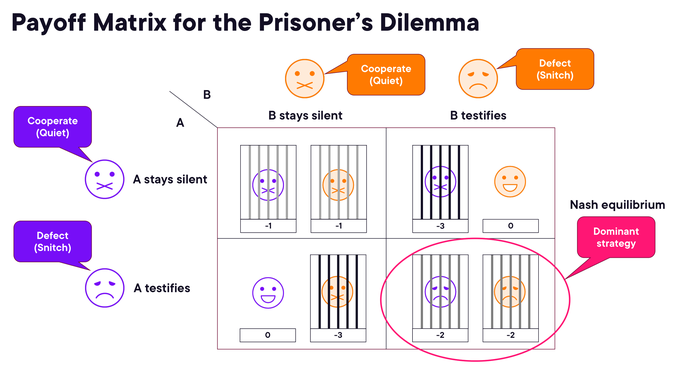

In [23]:
show('payoff-matrix-final.png', 25)

|  | **B stays silent** | **B testifies** |
|--|-------------------|-----------------|
| **A stays silent** | A: −1, B: −1 | A: −3, B: 0 |
| **A testifies** | A: 0, B: −3 | **A: −2, B: −2** ✓ Nash Equilibrium |

### Dominant Strategy


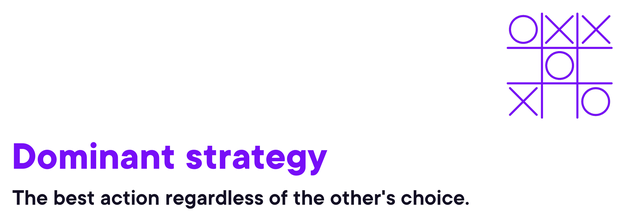

In [24]:
show('dominant-strategy.png', 25)

> **"The best action regardless of the other's choice."**

In the Prisoner's Dilemma, *Defect* is the dominant strategy for both players.

### Nash Equilibrium


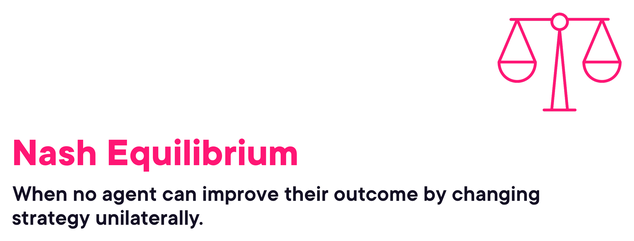

In [25]:
show('nash-equilibrium.png', 25)

> **"When no agent can improve their outcome by changing strategy unilaterally."**

*Both Defect* (−2, −2) is the Nash Equilibrium — even though *Both Cooperate* (−1, −1) is collectively better.

In [26]:
import numpy as np

payoffs_A = np.array([[-1, -3], [ 0, -2]])
payoffs_B = np.array([[-1,  0], [-3, -2]])
strategies = ['Cooperate (Silent)', 'Defect (Testify)']

print(f"{'Payoff Matrix (A_payoff, B_payoff)':45}")
print(f"{'':25} {'B: Cooperate':20} {'B: Defect':20}")
print('-' * 65)
for i, s in enumerate(strategies):
    cells = [f"({payoffs_A[i,j]:+d}, {payoffs_B[j,i]:+d})" for j in range(2)]
    ne = '  <- Nash Equilibrium' if i == 1 else ''
    print(f"A: {s:22} {cells[0]:20} {cells[1]:20}{ne if i==1 and cells[1]=='(-2, -2)' else ''}")

print("\nDominant Strategy : Defect (best regardless of other's choice)")
print("Nash Equilibrium  : Both Defect -> (-2, -2)")

Payoff Matrix (A_payoff, B_payoff)           
                          B: Cooperate         B: Defect           
-----------------------------------------------------------------
A: Cooperate (Silent)     (-1, -1)             (-3, -3)            
A: Defect (Testify)       (+0, +0)             (-2, -2)              <- Nash Equilibrium

Dominant Strategy : Defect (best regardless of other's choice)
Nash Equilibrium  : Both Defect -> (-2, -2)


---
### Game-theoretic Strategies Applied to LLM Agents

| Game Theory Concept | MAS Application |
|---------------------|-----------------|
| Zero-sum | Competitive agents bidding for resources |
| Mutually beneficial | Collaborative agents with shared goals |
| Auctions | Task/resource allocation between agents |
| Nash Equilibrium | Stable agent behavior in negotiation |
| Dominant Strategy | Default rational agent behavior |
| Contract Net | Structured task delegation and bidding |

**Demos:**
- **Auction-based system** — game-theoretic agentic system using LangGraph
- **Contract Net Protocol** — Lift Control Agentic System using LangGraph

---
## Course Summary

**The future of AI is agentic** — autonomy, interaction strategies, and system architectures.

| Topic | Key Takeaway |
|-------|--------------|
| Agent | Perceives and acts on its environment |
| MAS | Collection of autonomous agents in a shared environment |
| MAS types | Sequential, Hierarchical, Collaborative, Competitive |
| Topologies | Network (P2P), Supervisor, Hierarchical |
| LangGraph | State, Nodes, Edges, Command |
| Interaction | Cooperation, Collaboration, Negotiation, Competition, Adversarial |
| Negotiation | Auctions, Contract Net, Argumentation |
| Org structures | Hierarchies, Teams, Coalitions |
| Swarm | Handoff-based, tracks last active agent |
| Game Theory | Players, Strategies, Payoffs |
| Game kinds | Zero-sum, Mutually beneficial, Simultaneous, Sequential |
| Prisoner's Dilemma | Dominant strategy + Nash Equilibrium example |

**Further reading & demos:**
- 📚 [Module 1 Resources](demos/demo-1/demo-1-resources.ipynb) — LangGraph, agent protocols, teams & hierarchies
- 📚 [Module 2 Resources](demos/demo-2/demo-2-resources.ipynb) — Game theory, swarm, advanced architectures